In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
uwrfkaggler_ravdess_emotional_speech_audio_path = kagglehub.dataset_download('uwrfkaggler/ravdess-emotional-speech-audio')

print('Data source import complete.')


Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Data source import complete.


# Thống kê

In [2]:
import os
import pandas as pd
import numpy as np
import librosa
from scipy.signal import butter, lfilter
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from librosa.util import fix_length

# Đường dẫn dữ liệu RAVDESS
data_dir = "/kaggle/input/ravdess-emotional-speech-audio"

# Ánh xạ cảm xúc (mã hóa từ 0 đến 7)
emotion_map = {
    "01": (0, "neutral"),
    "02": (1, "calm"),
    "03": (2, "happy"),
    "04": (3, "sad"),
    "05": (4, "angry"),
    "06": (5, "fearful"),
    "07": (6, "disgust"),
    "08": (7, "surprised")
}

# Ánh xạ cường độ
intensity_map = {
    "01": "normal",
    "02": "strong"
}

# Ánh xạ câu nói
statement_map = {
    "01": "Kids are talking by the door",
    "02": "Dogs are sitting by the door"
}

# Tạo DataFrame từ RAVDESS
data = []
for actor_dir in os.listdir(data_dir):
    actor_path = os.path.join(data_dir, actor_dir)
    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith(".wav"):
                parts = file.split("-")
                emotion_code = parts[2]
                intensity_code = parts[3]
                statement_code = parts[4]
                actor_id = parts[6].split(".")[0]
                gender = "male" if int(actor_id) % 2 == 1 else "female"

                # Lấy mã cảm xúc (0-7)
                emotion_idx = emotion_map.get(emotion_code, (-1, "unknown"))[0]

                file_path = os.path.join(actor_path, file)
                data.append({
                    "file": file,
                    "emotion": emotion_idx,
                    "gender": gender,
                    "intensity": intensity_map.get(intensity_code, "unknown"),
                    "statement": statement_map.get(statement_code, "unknown"),
                    "actor_id": actor_id,
                    "file_path": file_path
                })
df = pd.DataFrame(data)

# Mã hóa các cột gender, intensity, statement
le_gender = LabelEncoder()
le_intensity = LabelEncoder()
le_statement = LabelEncoder()

df['gender'] = le_gender.fit_transform(df['gender'])
df['intensity'] = le_intensity.fit_transform(df['intensity'])
df['statement'] = le_statement.fit_transform(df['statement'])

# Thêm cột data_raw (tín hiệu thô)
df['data_raw'] = None
for idx, row in df.iterrows():
    audio, sr = librosa.load(row['file_path'], sr=48000)
    df.at[idx, 'data_raw'] = audio

# In mẫu DataFrame
print("Sample DataFrame:")
print(df[['file', 'emotion', 'gender', 'intensity', 'statement', 'actor_id', 'data_raw']].head())

Sample DataFrame:
                       file  emotion  gender  intensity  statement actor_id  \
0  03-01-08-01-01-01-02.wav        7       0          0          1       02   
1  03-01-01-01-01-01-02.wav        0       0          0          1       02   
2  03-01-07-02-01-02-02.wav        6       0          1          1       02   
3  03-01-07-01-01-02-02.wav        6       0          0          1       02   
4  03-01-01-01-02-01-02.wav        0       0          0          0       02   

                                            data_raw  
0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
3  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
4  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  


In [3]:
print(df.shape)


(1440, 8)


In [4]:
print(df.dtypes)

file         object
emotion       int64
gender        int64
intensity     int64
statement     int64
actor_id     object
file_path    object
data_raw     object
dtype: object


In [6]:
print(df.describe())

           emotion       gender    intensity    statement
count  1440.000000  1440.000000  1440.000000  1440.000000
mean      3.733333     0.500000     0.466667     0.500000
std       2.175356     0.500174     0.499061     0.500174
min       0.000000     0.000000     0.000000     0.000000
25%       2.000000     0.000000     0.000000     0.000000
50%       4.000000     0.500000     0.000000     0.500000
75%       6.000000     1.000000     1.000000     1.000000
max       7.000000     1.000000     1.000000     1.000000


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file       1440 non-null   object
 1   emotion    1440 non-null   int64 
 2   gender     1440 non-null   int64 
 3   intensity  1440 non-null   int64 
 4   statement  1440 non-null   int64 
 5   actor_id   1440 non-null   object
 6   file_path  1440 non-null   object
 7   data_raw   1440 non-null   object
dtypes: int64(4), object(4)
memory usage: 90.1+ KB
None


In [8]:
print(df.isnull().sum())

file         0
emotion      0
gender       0
intensity    0
statement    0
actor_id     0
file_path    0
data_raw     0
dtype: int64


emotion
7    192
6    192
5    192
3    192
2    192
1    192
4    192
0     96
Name: count, dtype: int64


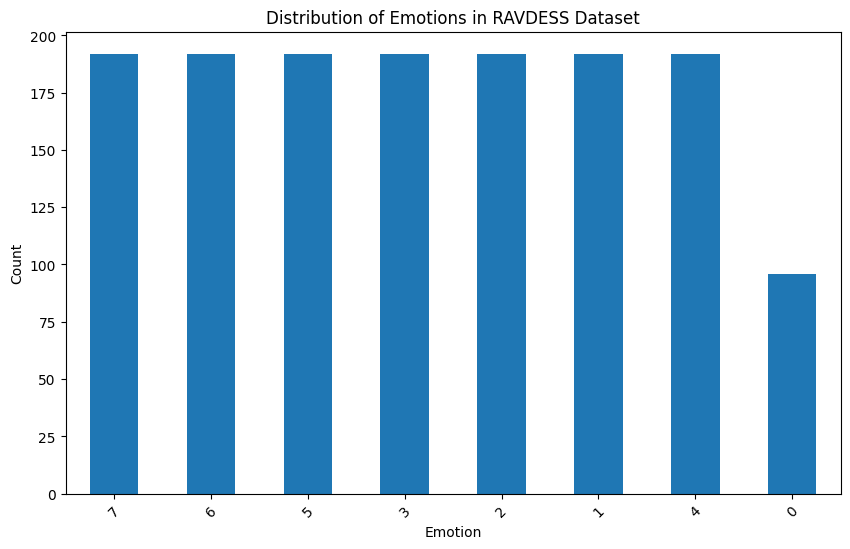

In [9]:

emotion_counts = df['emotion'].value_counts()
print(emotion_counts)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
emotion_counts.plot(kind='bar')
plt.title('Distribution of Emotions in RAVDESS Dataset')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

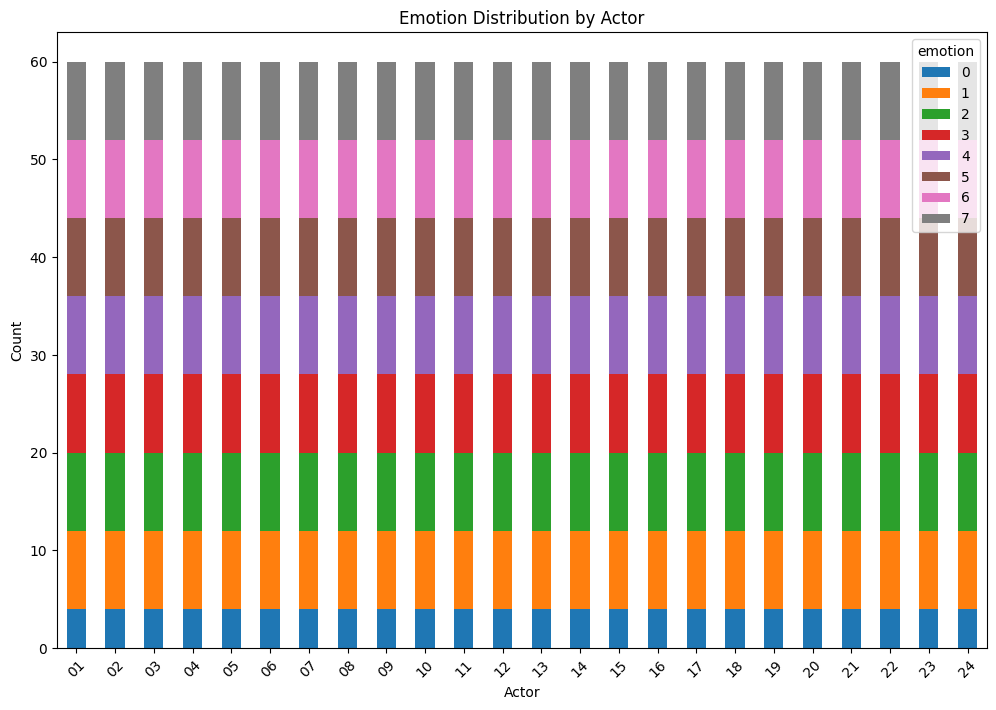

In [10]:

actor_emotion_counts = df.groupby('actor_id')['emotion'].value_counts().unstack()
actor_emotion_counts.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Emotion Distribution by Actor')
plt.xlabel('Actor')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [11]:
print(df["file"][0])
import librosa
file_path = df["file_path"][0]
audio, sr = librosa.load(file_path)  # audio: mảng tín hiệu, sr: tần số lấy mẫu

# In thông tin
print("Tín hiệu âm thanh:", audio)
print("Tần số lấy mẫu:", sr)

03-01-08-01-01-01-02.wav
Tín hiệu âm thanh: [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  3.3473766e-06
 -1.9576355e-06  1.3353035e-06]
Tần số lấy mẫu: 22050



=== Phân bố số lượng mẫu theo cảm xúc ===
emotion
surprised    192
disgust      192
fearful      192
sad          192
happy        192
calm         192
angry        192
neutral       96
Name: count, dtype: int64
Tổng số mẫu: 1440
Tỷ lệ mỗi lớp (%):
emotion
surprised    13.33
disgust      13.33
fearful      13.33
sad          13.33
happy        13.33
calm         13.33
angry        13.33
neutral       6.67
Name: count, dtype: float64


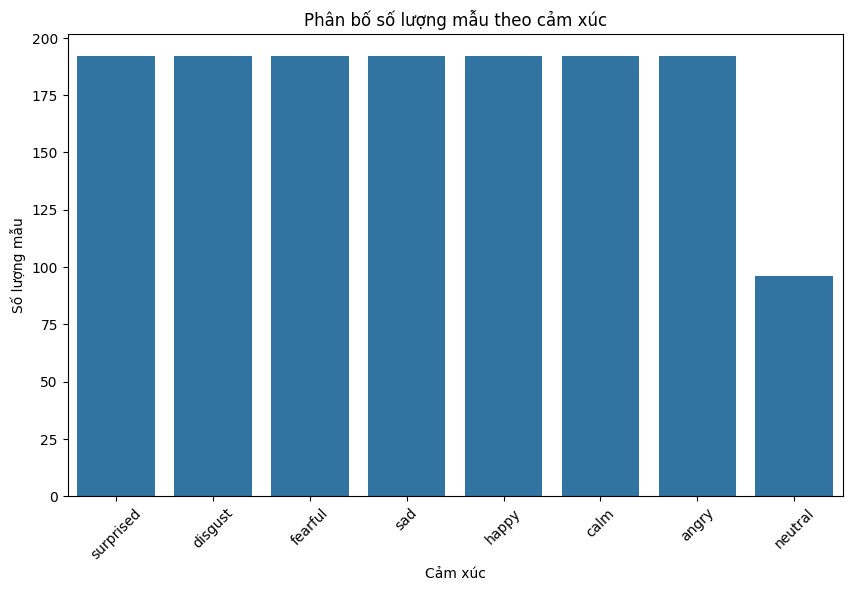


=== Thống kê thời lượng âm thanh (giây) ===


In [ ]:
import os
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import gc

data_dir = "/kaggle/input/ravdess-emotional-speech-audio"


emotion_map = {
    "01": (0, "neutral"), "02": (1, "calm"), "03": (2, "happy"), "04": (3, "sad"),
    "05": (4, "angry"), "06": (5, "fearful"), "07": (6, "disgust"), "08": (7, "surprised")
}
intensity_map = {"01": "normal", "02": "strong"}
statement_map = {
    "01": "Kids are talking by the door",
    "02": "Dogs are sitting by the door"
}

data = []
for actor_dir in os.listdir(data_dir):
    actor_path = os.path.join(data_dir, actor_dir)
    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith(".wav"):
                parts = file.split("-")
                emotion_code = parts[2]
                intensity_code = parts[3]
                statement_code = parts[4]
                actor_id = parts[6].split(".")[0]
                gender = "male" if int(actor_id) % 2 == 1 else "female"
                emotion_idx, emotion_name = emotion_map.get(emotion_code, (-1, "unknown"))
                file_path = os.path.join(actor_path, file)
                data.append({
                    "file_path": file_path,
                    "emotion": emotion_name,
                    "emotion_idx": emotion_idx,
                    "gender": gender,
                    "intensity": intensity_map.get(intensity_code, "unknown"),
                    "statement": statement_map.get(statement_code, "unknown"),
                    "actor_id": actor_id
                })
df = pd.DataFrame(data)
gc.collect()

print("\n=== Phân bố số lượng mẫu theo cảm xúc ===")
emotion_counts = df['emotion'].value_counts()
print(emotion_counts)
print(f"Tổng số mẫu: {len(df)}")
print(f"Tỷ lệ mỗi lớp (%):")
print((emotion_counts / len(df) * 100).round(2))


plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.title("Phân bố số lượng mẫu theo cảm xúc")
plt.xlabel("Cảm xúc")
plt.ylabel("Số lượng mẫu")
plt.xticks(rotation=45)
plt.show()

print("\n=== Thống kê thời lượng âm thanh (giây) ===")
durations = []
for file_path in df['file_path']:
    audio, sr = librosa.load(file_path, sr=48000)
    duration = librosa.get_duration(y=audio, sr=sr)
    durations.append(duration)
    gc.collect()

durations = np.array(durations)
print(f"Thời lượng trung bình: {durations.mean():.2f} giây")
print(f"Độ lệch chuẩn: {durations.std():.2f} giây")
print(f"Thời lượng tối thiểu: {durations.min():.2f} giây")
print(f"Thời lượng tối đa: {durations.max():.2f} giây")

plt.figure(figsize=(10, 6))
sns.histplot(durations, bins=30, kde=True)
plt.title("Phân bố thời lượng âm thanh")
plt.xlabel("Thời lượng (giây)")
plt.ylabel("Tần suất")
plt.show()

print("\n=== Phân bố diễn viên theo giới tính ===")
gender_counts = df['gender'].value_counts()
print(gender_counts)
print(f"Tỷ lệ giới tính (%):")
print((gender_counts / len(df) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.barplot(x=gender_counts.index, y=gender_counts.values)
plt.title("Phân bố diễn viên theo giới tính")
plt.xlabel("Giới tính")
plt.ylabel("Số lượng mẫu")
plt.show()

print("\n=== Phân bố câu nói ===")
statement_counts = df['statement'].value_counts()
print(statement_counts)
print(f"Tỷ lệ câu nói (%):")
print((statement_counts / len(df) * 100).round(2))


plt.figure(figsize=(8, 5))
sns.barplot(x=statement_counts.index, y=statement_counts.values)
plt.title("Phân bố câu nói")
plt.xlabel("Câu nói")
plt.ylabel("Số lượng mẫu")
plt.xticks(rotation=45)
plt.show()

df['repetition'] = df['file_path'].apply(lambda x: os.path.basename(x).split('-')[5])
print("\n=== Phân bố lần lặp ===")
repetition_counts = df['repetition'].value_counts()
print(repetition_counts)
print(f"Tỷ lệ lần lặp (%):")
print((repetition_counts / len(df) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.barplot(x=repetition_counts.index, y=repetition_counts.values)
plt.title("Phân bố lần lặp")
plt.xlabel("Lần lặp")
plt.ylabel("Số lượng mẫu")
plt.show()

print("\n=== Thống kê đặc trưng MFCC (mẫu đầu tiên) ===")
def extract_mfcc_stats(file_path, n_mfcc=40, sr=48000):
    audio, sr = librosa.load(file_path, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc, n_fft=1024, hop_length=256)
    return {
        'mean': np.mean(mfcc, axis=1),
        'std': np.std(mfcc, axis=1),
        'skew': skew(mfcc, axis=1),
        'kurtosis': kurtosis(mfcc, axis=1)
    }

sample_mfcc_stats = extract_mfcc_stats(df['file_path'].iloc[0])
print("MFCC (40 hệ số) - Thống kê cho mẫu đầu tiên:")
print(f"Trung bình: {sample_mfcc_stats['mean'][:5]} (5 hệ số đầu)")
print(f"Độ lệch chuẩn: {sample_mfcc_stats['std'][:5]} (5 hệ số đầu)")
print(f"Độ lệch: {sample_mfcc_stats['skew'][:5]} (5 hệ số đầu)")
print(f"Độ nhọn: {sample_mfcc_stats['kurtosis'][:5]} (5 hệ số đầu)")

plt.figure(figsize=(10, 6))
plt.plot(sample_mfcc_stats['mean'], label='Mean')
plt.plot(sample_mfcc_stats['std'], label='Std')
plt.plot(sample_mfcc_stats['skew'], label='Skew')
plt.plot(sample_mfcc_stats['kurtosis'], label='Kurtosis')
plt.title("Thống kê MFCC (Mẫu đầu tiên)")
plt.xlabel("Hệ số MFCC")
plt.ylabel("Giá trị")
plt.legend()
plt.show()

gc.collect()

In [ ]:
def get_channels(file_path):
    y, sr = librosa.load(file_path, sr=None)
    return "mono" if y.ndim == 1 else "stereo"
channels = [get_channels(file) for file in df["file_path"]]
mono_count = channels.count("mono")
stereo_count = channels.count("stereo")


plt.figure(figsize=(6, 4))
plt.bar(["Mono", "Stereo"], [mono_count, stereo_count], color=['blue', 'orange'], edgecolor='black')
plt.title("Phân bố số lượng kênh trong RAVDESS")
plt.xlabel("Loại kênh")
plt.ylabel("Số lượng tệp")
plt.show()

print(f"Số lượng tệp mono: {mono_count}")
print(f"Số lượng tệp stereo: {stereo_count}")

In [ ]:

sample_rates = []
for path in df['file_path']:
    try:
        _, sr = librosa.load(path, sr=None)
        sample_rates.append(sr)
    except Exception as e:
        print(f"Lỗi đọc {path}: {e}")
        sample_rates.append(None)


df['sample_rate'] = sample_rates
print("\nTần số lấy mẫu phổ biến:")
print(df['sample_rate'].value_counts())
import matplotlib.pyplot as plt

sample_rate_counts = df['sample_rate'].value_counts().sort_index()


plt.figure(figsize=(10, 6))
sample_rate_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Phân bố tần số lấy mẫu của các file audio')
plt.xlabel('Tần số lấy mẫu (Hz)')
plt.ylabel('Số lượng file')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# Tiền xử lý dữ liệu thô


In [ ]:
df = df[['emotion', 'gender', 'intensity', 'statement', 'actor_id', 'data_raw']]
import IPython.display as ipd



In [ ]:
sr = 48000
durations = df['data_raw'].apply(lambda x: len(x) / sr)
# durations = df['data_raw_clean'].apply(lambda x: len(x) / sr)
average_duration = durations.mean()
print(f"Thời gian trung bình: {average_duration:.2f} giây")


In [ ]:

ipd.Audio(df['data_raw_clean'][1], rate = sr)

## Cắt

In [ ]:
import numpy as np
import librosa

def remove_silence(audio, sr, frame_length=2048, hop_length=512, top_db=30):
    intervals = librosa.effects.split(audio, top_db=top_db, frame_length=frame_length, hop_length=hop_length)
    audio_clean = np.concatenate([audio[start:end] for start, end in intervals])
    return audio_clean
df['data_raw_clean'] = df['data_raw'].apply(lambda x: remove_silence(x, sr=16000))


In [ ]:
import IPython.display as ipd
ipd.Audio(df["data_raw_pitch"][2], rate = sr)

## Lọc nhiễu

In [ ]:
from scipy.signal import butter, lfilter

def denoise_audio(audio, sr=48000, cutoff=4000, order=5):
    nyquist = 0.5 * sr
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    audio_denoised = lfilter(b, a, audio)
    return audio_denoised
df['data_raw_butter'] = df['data_raw_clean'].apply(lambda x: denoise_audio(x, sr=48000))

## Time stretch

In [ ]:
def stretch(data, rate=1):
    return librosa.effects.time_stretch(y=data, rate=rate)

df['data_raw_time'] = df['data_raw_butter'].apply(lambda x: stretch(x, rate=1))

## Thêm nhiễu

In [ ]:
def add_noise(audio, noise_factor=0.005):
    noise = np.random.randn(len(audio))
    audio_noise = audio + noise_factor * noise
    return audio_noise
df['data_raw_time'] = df['data_raw_time'].apply(lambda x: add_noise(x, noise_factor=0.005))

In [ ]:
()

In [ ]:
import IPython.display as ipd
ipd.Audio(df['data_raw_time'][0], rate = 48000)

In [ ]:
def time_shift(audio, shift_max=0.2, sr=48000):
    shift = int(np.random.uniform(-shift_max, shift_max) * sr)
    return np.roll(audio, shift)
df['data_raw_time'] = df['data_raw_butter'].apply(lambda x: time_shift(x, shift_max=0.2, sr=48000))

In [ ]:
def volume_change(audio, gain=1.5):
    return audio * gain
df['data_raw_time'] = df['data_raw_butter'].apply(lambda x: volume_change(x, gain=1.5))

# Trích xuất đặc trưng

In [ ]:
# df = df[['data_raw', 'data_raw_time', 'emotion']].copy()
import gc
gc.collect()


In [ ]:
import librosa

def extract_mfcc(audio, sr=48000, n_mfcc=13):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    return mfcc

df['mfcc'] = df['data_raw_time'].apply(lambda x: extract_mfcc(x))


In [ ]:
def extract_log_mel_spectrogram(audio ,n_mels=128, n_fft=2048, hop_length=512):
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length, window='hamming')
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    return log_mel_spec
# df['log_mel_spec'] = df['data_raw_time'].apply(lambda x: extract_log_mel_spectrogram(x))

### Làm mịn

In [ ]:
from scipy.signal import savgol_filter

def smooth_audio(audio, window_length=11, polyorder=2):
    audio_smoothed = savgol_filter(audio, window_length, polyorder)
    return audio_smoothed

### Chuẩn hóa

In [ ]:
def normalize_mfcc(mfcc):
    scaler = StandardScaler()
    return scaler.fit_transform(mfcc.T).T
# df['mfcc_norm'] = df['mfcc_smooth'].apply(lambda x: normalize_mfcc(x))

### Padding


In [ ]:
def pad_mfcc(mfcc):
    return fix_length(mfcc, size=2048, axis=1)

# df['m_spec'] = df['log_mel_spec'].apply(lambda x: pad_mfcc(x))


In [ ]:
def preprocess_audio(column):
  c = column
  df[c] = df['data_raw_butter'].apply(lambda x: extract_mfcc(x))
  df[c] = df[c].apply(lambda x: smooth_mfcc(x,3))
  df[c] = df[c].apply(lambda x: normalize_mfcc(x))
  df[c] = df[c].apply(lambda x: pad_mfcc(x))
preprocess_audio('mfcc_pre')

In [ ]:
df.head()

In [ ]:
def extract_mfcc_deltas(mfcc_2d):
    delta = librosa.feature.delta(mfcc_2d)
    delta_delta = librosa.feature.delta(mfcc_2d, order=2)

    features = np.concatenate([
        np.mean(mfcc_2d, axis=1), np.std(mfcc_2d, axis=1),
        np.mean(delta, axis=1), np.std(delta, axis=1),
        np.mean(delta_delta, axis=1), np.std(delta_delta, axis=1)
    ])
    return features

df['mfcc_pre'] = df['mfcc_pre'].apply(extract_mfcc_deltas)
X = np.stack(df['mfcc_pre'].values)

# ML

In [ ]:
import gc
X = np.stack(df['mfcc_pre'].values)
gc.collect()
df = df[['emotion', 'gender', 'intensity', 'statement', 'actor_id', 'mfcc_pre']]

### Chuẩn bị dữ liệu

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# mfcc_flat = np.array([spec.flatten() for spec in df['mfcc_pre']])
additional_features = df[['gender', 'intensity', 'statement']].values
X = np.hstack((X, additional_features))
y = df['emotion'].values  # Nhãn emotion (0-7)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Kích thước tập huấn luyện:", X_train.shape)
print("Kích thước tập kiểm tra:", X_test.shape)
print("Số lớp nhãn:", len(np.unique(y)))

In [ ]:
# print(X)
print(df.head())

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

models = {
    'Random Forest': RandomForestClassifier(n_estimators=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=10),
    'SVM': SVC(kernel='rbf', random_state=42)
}

for name, model in models.items():
    print(f"\n=== Huấn luyện mô hình: {name} ===")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Độ chính xác: {accuracy:.4f}")
    print("Báo cáo phân loại:")
    print(classification_report(y_test, y_pred, target_names=[
    'neutral_calm',        # emotion = 1
    'happy_intensity_1',   # emotion = 2
    'sad_intensity_1',     # emotion = 3
    'angry_intensity_1',   # emotion = 4
    'fearful_intensity_1', # emotion = 5
    'disgust_intensity_1', # emotion = 6
    'surprised_intensity_1', # emotion = 7
]))

# Trích xuất đặc trưng và trực quan dữ liệu đặc trưng

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Load file âm thanh
y_1, sr = librosa.load('/kaggle/input/ravdess-emotional-speech-audio/Actor_01/03-01-01-01-01-01-01.wav')
y_2, sr = librosa.load('/kaggle/input/ravdess-emotional-speech-audio/Actor_01/03-01-02-01-01-01-01.wav')
y_3, sr = librosa.load('/kaggle/input/ravdess-emotional-speech-audio/Actor_01/03-01-03-01-01-01-01.wav')
y_4, sr = librosa.load('/kaggle/input/ravdess-emotional-speech-audio/Actor_01/03-01-04-01-01-01-01.wav')
y_5, sr = librosa.load('/kaggle/input/ravdess-emotional-speech-audio/Actor_01/03-01-05-01-01-01-01.wav')
y_6, sr = librosa.load('/kaggle/input/ravdess-emotional-speech-audio/Actor_01/03-01-06-01-01-01-01.wav')
y_7, sr = librosa.load('/kaggle/input/ravdess-emotional-speech-audio/Actor_01/03-01-07-01-01-01-01.wav')
y_8, sr = librosa.load('/kaggle/input/ravdess-emotional-speech-audio/Actor_01/03-01-08-01-01-01-01.wav')



In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

mfccs = librosa.feature.mfcc(y=y_1, sr=sr, n_mfcc=13)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, x_axis='time', sr=sr)
plt.colorbar()
plt.title('MFCCs')
plt.tight_layout()
plt.show()
y_1.shape
mfccs.shape

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os
n_files = 8
n_mfcc = 13
colormap = 'viridis'

signals = [y_1, y_2, y_3, y_4, y_5, y_6, y_7, y_8]
plt.figure(figsize=(20, 10))

for i in range(1, n_files + 1):

    mfccs = librosa.feature.mfcc(y=signals[i-1], sr=sr, n_mfcc=n_mfcc)

    # Vẽ MFCCs trong subplot
    plt.subplot(2, 4, i)  # 2 hàng, 4 cột (tổng 8 ô)
    librosa.display.specshow(mfccs, x_axis='time', sr=sr, cmap=colormap)
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'File {i} MFCCs', fontsize=10)

plt.tight_layout()  # Tự động căn chỉnh khoảng cách
plt.suptitle('MFCCs 8 file cảm xúc khác nhau', y=1.02, fontsize=14)
plt.show()

In [ ]:
# Trích xuất Chroma Feature
chroma = librosa.feature.chroma_stft(y=y, sr=sr)

# Trực quan hóa
plt.figure(figsize=(10, 4))
librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', sr=sr, cmap='coolwarm')
plt.colorbar()
plt.title('Chroma Features')
plt.tight_layout()
plt.show()

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

plt.figure(figsize=(20, 10))

for i in range(n_files):

    chroma = librosa.feature.chroma_stft(y=signals[i-1], sr=sr)

    # Vẽ Chroma trong subplot
    plt.subplot(2, 4, i + 1)  # Lưới 2x4
    librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', sr=sr, cmap=colormap)
    plt.colorbar()  # Không cần định dạng dB
    plt.title(f'File {i + 1} Chroma', fontsize=10)

# Điều chỉnh bố cục và thêm tiêu đề chung
plt.tight_layout()
plt.suptitle('Chroma 8 file cảm xúc khác nhau', y=1.02, fontsize=14)
plt.show()

In [ ]:
# Tính Spectrogram
D = librosa.amplitude_to_db(librosa.stft(y_1), ref=np.max)

# Trực quan hóa
plt.figure(figsize=(10, 4))
librosa.display.specshow(D, x_axis='time', y_axis='log', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.tight_layout()
plt.show()

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

plt.figure(figsize=(20, 10))

# Lặp qua từng file âm thanh
for i in range(n_files):

    D = librosa.stft(signals[i])
    D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)  # Chuyển sang thang dB

    # Vẽ Spectrogram trong subplot
    plt.subplot(2, 4, i + 1)  # Lưới 2x4
    librosa.display.specshow(D_db, x_axis='time', y_axis='hz', sr=sr, cmap=colormap)
    plt.colorbar(format='%+2.0f dB')  # Định dạng dB phù hợp
    plt.title(f'File {i + 1} Spectrogram', fontsize=10)

# Điều chỉnh bố cục và thêm tiêu đề chung
plt.tight_layout()
plt.suptitle('Spectrogram 8 file cảm xúc khác nhau', y=1.02, fontsize=14)
plt.show()

In [ ]:
# Trích xuất ZCR
zcr = librosa.feature.zero_crossing_rate(y_1)

# Trực quan hóa
plt.figure(figsize=(10, 4))
time_wave = np.linspace(0, len(y) / sr, len(y))
plt.plot(time_wave, y, color='lightblue', alpha=0.5, label='Waveform')

    # Tính và vẽ ZCR
zcr = librosa.feature.zero_crossing_rate(y)[0]
frame_length = 2048
hop_length = 512
time_zcr = np.arange(len(zcr)) * hop_length / sr
plt.plot(time_zcr, zcr, color=colors[i], linewidth=2, label='ZCR')

plt.title('Zero-Crossing Rate')
plt.xlabel('Time(s)')
plt.ylabel('ZCR')
plt.tight_layout()
plt.show()

In [ ]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

# Tham số
n_files = 8
signals = [y_1, y_2, y_3, y_4, y_5, y_6, y_7, y_8]  # Danh sách tín hiệu của bạn
sr = 22050  # Thay bằng tần số mẫu thực tế của bạn
colormap = 'viridis'
colors = plt.get_cmap(colormap)(np.linspace(0, 1, n_files))

# Tạo figure
plt.figure(figsize=(20, 12))

# Lặp qua từng tín hiệu
for i in range(n_files):
    y = signals[i]

    # Tạo subplot
    plt.subplot(2, 4, i + 1)

    # Vẽ Waveform
    time_wave = np.linspace(0, len(y) / sr, len(y))
    plt.plot(time_wave, y, color='lightblue', alpha=0.5, label='Waveform')

    # Tính và vẽ ZCR
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    frame_length = 2048
    hop_length = 512
    time_zcr = np.arange(len(zcr)) * hop_length / sr
    plt.plot(time_zcr, zcr, color=colors[i], linewidth=2, label='ZCR')

    # Thiết lập trục và nhãn
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude / ZCR')
    plt.title(f'File {i + 1} Waveform & ZCR', fontsize=10)
    plt.legend()
    plt.grid(True)
    plt.ylim(-1.5, 1.5)

# Điều chỉnh bố cục và thêm tiêu đề chung
plt.tight_layout()
plt.suptitle('Waveform và Zero Crossing Rate 8 file cảm xúc khác nhau', y=1.02, fontsize=14)
plt.show()

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

# Tham số
n_files = 8
audio_files = [f'file{i}.wav' for i in range(1, n_files + 1)]  # Danh sách file âm thanh
colormap = 'viridis'
colors = plt.get_cmap(colormap)(np.linspace(0, 1, n_files))  # Màu từ colormap

# 1. Vẽ Spectral Centroid
plt.figure(figsize=(20, 10))
for i in range(n_files):

    spectral_centroid = librosa.feature.spectral_centroid(y=signals[i], sr=sr)[0]
    frame_length = 2048
    hop_length = 512
    time = np.arange(len(spectral_centroid)) * hop_length / sr
    plt.subplot(2, 4, i + 1)
    plt.plot(time, spectral_centroid, color=colors[i])
    plt.xlabel('Time (s)')
    plt.ylabel('Spectral Centroid (Hz)')
    plt.title(f'File {i + 1} Spectral Centroid', fontsize=10)
    plt.grid(True)
plt.tight_layout()
plt.suptitle('Spectral Centroid 8 file cảm xúc khác nhau', y=1.02, fontsize=14)
plt.show()

plt.figure(figsize=(20, 10))
for i in range(n_files):

    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=signals[i], sr=sr)[0]
    frame_length = 2048
    hop_length = 512
    time = np.arange(len(spectral_bandwidth)) * hop_length / sr
    plt.subplot(2, 4, i + 1)
    plt.plot(time, spectral_bandwidth, color=colors[i])
    plt.xlabel('Time (s)')
    plt.ylabel('Spectral Bandwidth (Hz)')
    plt.title(f'File {i + 1} Spectral Bandwidth', fontsize=10)
    plt.grid(True)
plt.tight_layout()
plt.suptitle('Spectral Bandwidth 8 file cảm xúc khác nhau', y=1.02, fontsize=14)
plt.show()


plt.figure(figsize=(20, 10))
for i in range(n_files):

    spectral_contrast = librosa.feature.spectral_contrast(y=signals[i], sr=sr)
    frame_length = 2048
    hop_length = 512
    time = np.arange(spectral_contrast.shape[1]) * hop_length / sr
    plt.subplot(2, 4, i + 1)
    for band in range(spectral_contrast.shape[0]):
        plt.plot(time, spectral_contrast[band], color=colors[i], alpha=0.6)
    plt.xlabel('Time (s)')
    plt.ylabel('Spectral Contrast')
    plt.title(f'File {i + 1} Spectral Contrast', fontsize=10)
    plt.grid(True)
plt.tight_layout()
plt.suptitle('Spectral Contrast 8 file cảm xúc khác nhau', y=1.02, fontsize=14)
plt.show()

plt.figure(figsize=(20, 10))
for i in range(n_files):

    spectral_flatness = librosa.feature.spectral_flatness(y=signals[i])[0]
    frame_length = 2048
    hop_length = 512
    time = np.arange(len(spectral_flatness)) * hop_length / sr
    plt.subplot(2, 4, i + 1)
    plt.plot(time, spectral_flatness, color=colors[i])
    plt.xlabel('Time (s)')
    plt.ylabel('Spectral Flatness')
    plt.title(f'File {i + 1} Spectral Flatness', fontsize=10)
    plt.grid(True)
    plt.ylim(0, 1)  # Spectral Flatness thường nằm trong khoảng [0, 1]
plt.tight_layout()
plt.suptitle('Spectral Flatness 8 file cảm xúc khác nhau', y=1.02, fontsize=14)
plt.show()